<a href="https://colab.research.google.com/github/zhilyaevaviktorija/machine_learning/blob/main/homeworks/Homework_3_%22log_reg_hw_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание: линейные модели для NLP**

## **Что будем делать?**
Мы будем предсказывать, к какой категории относится новость: про хоккей или про космос.

## **Часть 1. Практическая работа (8 баллов)**

### **1. Загрузка данных**

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups

# Загружаем данные о новостях
categories = ['rec.sport.hockey', 'sci.space']
newsgroups = fetch_20newsgroups(subset='all',
                               categories=categories,
                               shuffle=True,
                               random_state=42)

# Создаём таблицу с данными
data = pd.DataFrame({
    'text': newsgroups.data,
    'category': newsgroups.target  # 0 = хоккей, 1 = космос
})

print("Размер данных:", data.shape)
print("\nПервые 3 текста:")
for i in range(3):
    print(f"Текст {i+1}: {data['text'][i][:100]}...")

Размер данных: (1986, 2)

Первые 3 текста:
Текст 1: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I....
Текст 2: From: epritcha@s.psych.uiuc.edu ( Evan Pritchard)
Subject: Re: div. and conf. names
Distribution: na...
Текст 3: From: baalke@kelvin.jpl.nasa.gov (Ron Baalke)
Subject: Galileo Update - 04/29/93
Keywords: Galileo, ...


**Задание 1:**
- Сколько всего текстов в датасете?
- Выведите количество текстов в каждой категории

In [36]:
# Всего 1986 текстов

# Выводим количество текстов в каждой категории
category_counts = data['category'].value_counts()
print("Количество текстов по категориям:")
print(f"Хоккей (0): {category_counts[0]} текстов")
print(f"Космос (1): {category_counts[1]} текстов")

Количество текстов по категориям:
Хоккей (0): 999 текстов
Космос (1): 987 текстов


### **2. Анализ данных**

In [37]:
# Ваш код здесь
# Подсказка: используйте value_counts()

# Определяем, какая категория больше
if category_counts[0] > category_counts[1]:
    print("Категория 'Хоккей' больше")
elif category_counts[1] > category_counts[0]:
    print("Категория 'Космос' больше")
else:
    print("Категории равны")

# Категория 'Хоккей' больше

Категория 'Хоккей' больше


**Вопрос:** Какая категория больше: хоккей или космос?

### **3. Очистка текста**

In [38]:
import re

def clean_text(text):
    # Ваш код здесь
    # 1. Привести текст к нижнему регистру (.lower())
    text = text.lower()

    # 2. Удалить всё, кроме букв и пробелов (re.sub)
    text = re.sub(r'[^a-zа-я\s]', '', text)

    # 3. Убрать лишние пробелы
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Применяем функцию
data['clean_text'] = data['text'].apply(clean_text)

# Проверяем
print("До очистки:", data['text'][0][:100])
print("\nПосле очистки:", data['clean_text'][0][:100])

До очистки: From: mccall@mksol.dseg.ti.com (fred j mccall 575-3539)
Subject: Re: Vandalizing the sky.
Article-I.

После очистки: from mccallmksoldsegticom fred j mccall subject re vandalizing the sky articleid mksolapr organizati


### **4. Создание признаков (векторизация)**

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

# Ваш код здесь
# 1. Создайте CountVectorizer (остановитесь на английском)
vectorizer = CountVectorizer(stop_words='english')

# 2. Преобразуйте тексты в числа (fit_transform)
X = vectorizer.fit_transform(data['clean_text'])

# 3. Выведите сколько слов получилось
print(f"Количество уникальных слов: {X.shape[1]}")

# Количество уникальных слов: 28383

Количество уникальных слов: 28383


**Вопрос:** Сколько уникальных слов нашёл CountVectorizer?

### **5. Разделение данных**

In [40]:
from sklearn.model_selection import train_test_split

# Цель: предсказать категорию (0 или 1)
X = vectorizer.fit_transform(data['clean_text']) # что сюда подставить? (признаки)
y = data['category']                             # что сюда подставить? (целевая переменная)

# Ваш код здесь
# Разделите данные на 80% обучение, 20% тест
# Используйте random_state=42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]} текстов")
print(f"Размер тестовой выборки: {X_test.shape[0]} текстов")
print(f"Всего: {X.shape[0]} текстов")

Размер обучающей выборки: 1588 текстов
Размер тестовой выборки: 398 текстов
Всего: 1986 текстов


### **6. Обучение модели**

In [41]:
from sklearn.linear_model import LogisticRegression

# Ваш код здесь
# 1. Создайте модель логистической регрессии
model = LogisticRegression()

# 2. Обучите её на обучающих данных
model.fit(X_train, y_train)

# 3. Сделайте предсказания для тестовых данных
y_pred = model.predict(X_test)

### **7. Оценка модели**

In [42]:
from sklearn.metrics import accuracy_score

# Ваш код здесь
# 1. Вычислите accuracy (точность) модели
accuracy = accuracy_score(y_test, y_pred)

# 2. Выведите результат в процентах
print(f"Accuracy модели: {accuracy:.4f}")
print(f"Accuracy модели в процентах: {accuracy * 100:.2f}%")

# Accuracy модели: 0.9925
# Accuracy модели в процентах: 99.25%
# Модель отлично классифицирует тексты про хоккей и космос
# Из 100 текстов модель ошибается только в одном случае

Accuracy модели: 0.9925
Accuracy модели в процентах: 99.25%


**Вопрос:** Какая точность у вашей модели? Что это значит?

### **8. Анализ ошибок**

Матрица ошибок (confusion matrix):
[[201   1]
 [  2 194]]


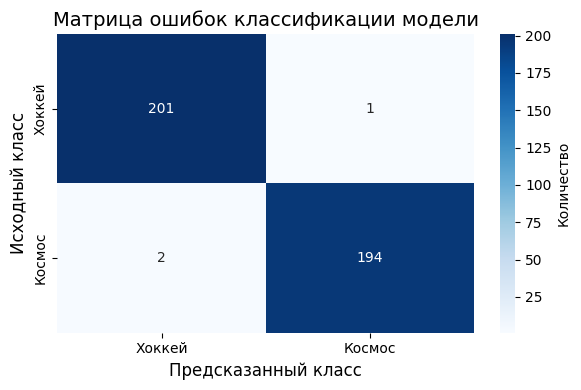

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ваш код здесь
# 1. Создайте матрицу ошибок
cm = confusion_matrix(y_test, y_pred)

# 2. Выведите её
print("Матрица ошибок (confusion matrix):")
print(cm)


# БОНУС: визуализируйте матрицу ошибок
# Ваш код для визуализации здесь
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Хоккей', 'Космос'],
            yticklabels=['Хоккей', 'Космос'], cbar_kws={'label': 'Количество'})
plt.title('Матрица ошибок классификации модели', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Исходный класс', fontsize=12)
plt.tight_layout()
plt.show()

# Модель ошибочно приняла 1 текст про космос за хоккей

**Вопрос:** Сколько текстов про космос модель приняла за хоккей?